# Speciation Analysis for QMD Simulations (VASP / LAMMPS)

**Purpose:** Identify and track chemical species (molecules, clusters, isolated atoms)
in quantum molecular dynamics trajectories from VASP or LAMMPS.

**Algorithm overview:**
1. Load trajectory into an MDAnalysis Universe (supports VASP XDATCAR or LAMMPS dump).
2. At each timestep, compute pairwise distances and rank neighbors for every atom.
3. Over a sliding time window (bond-persistence criterion), identify atom pairs that
   remain mutual nearest neighbors.
4. Cluster atoms into molecules using a top-down approach (largest clusters first)
   to avoid double-counting.
5. Classify each cluster by its chemical composition and track populations over time.


**Pre-requisites:**
- Python 3.x / Numpy
- MDAnalysis
- ASE
- PyMatGen
- e.g., conda create -n spec_analysis mdanalysis ase pymatgen -y

**Originally developed for H₂O–H₂ systems; generalized to arbitrary multi-element systems.**

**Authors: Akash Gupta and Austin Guo, refined by Claude.**

## 1. Configuration

In [1]:
# ---- Reference: Vibrational Periods of Common Bonds ----
# These help guide the bond_persistence_steps parameter.
# The persistence window should be at least one vibrational period
# so that transient close encounters are not mistaken for bonds.
#
# Source: https://www.chem.purdue.edu/gchelp/vibs/index.html
#         + NIST Webbook (https://webbook.nist.gov)
#
# Period = 1 / (c * wavenumber)
# where c = 2.998e10 cm/s and wavenumber is in cm^-1.
#
# --- Bonds relevant to MgSiO3 + H2 + NH3 + H2O system ---
# Elements: Mg, Si, O, N, H
#
#   Bond     Wavenumber (cm^-1)    Period (fs)    Context
#   ----     ------------------    -----------    -------
#   H-H         4342                  7.68        H2 molecule
#   O-H         3506                  9.51        H2O asymmetric stretch
#   O-H         3592                  9.29        H2O symmetric stretch
#   N-H         3337                  9.99        NH3 asymmetric stretch
#   N-H         3444                  9.68        NH3 symmetric stretch
#   Si-O        1050                 31.75        SiO4 tetrahedra (stretch)
#   Si-O         800                 41.69        SiO4 tetrahedra (bend)
#   Mg-O         500                 66.71        MgO octahedra
#   O-O         2061                 16.18        O2 molecule (if present)
#   N-N         2331                 14.30        N2 molecule (if present)
#   N-O         1876                 17.77        NO molecule
#   Si-H        2200                 15.15        SiH4 (if present)
#   Si-N         950                 35.11        Si3N4
#   Mg-H        1500                 22.24        MgH2 (if present)
#   Mg-N         600                 55.59        Mg3N2
#   Si-Si        510                 65.41        Si-Si in silicates
#   Mg-Si        ~400                ~83.4        (estimated, ionic/metallic)
#   Mg-Mg        ~300               ~111.2        (estimated, metallic)
#   H-O-H       1595                 20.91        H2O bend
#   H-N-H       1627                 20.50        NH3 bend
#   O-Si-O       450                 74.13        SiO4 bend
#
# Example: for POTIM = 0.5 fs, the Mg-O period is ~66.7 fs = ~133 steps.
# A safe bond_persistence_steps would be >= max vibrational period / POTIM.
# For this system, the slowest mode is Mg-O (~67 fs), so persistence >= 134
# steps at POTIM = 0.5 fs.

In [2]:
# ---- User Configuration ----
# Set these parameters before running the notebook.

# Run identifier (used to locate the data directory)
# run_id = "a0852t"
run_id = "blob_test3"

# Base directory containing simulation run folders
# data_base_dir = "/Users/akashgpt/akashgpt_local_desktop/Research/qmd_data/H2O_H2/speciation_analysis_testing_dataset"
data_base_dir = "/projects/JIEDENG/akashgpt/shared_w_Donghao/For_Akash"

# Input format: 'vasp' or 'lammps'
sim_format = "vasp"

# --- Output location ---
# "here"      -> save outputs next to this notebook (./analysis/speciation/{run_id}/)
# "with_data" -> save outputs in the data directory ({run_dir}/analysis/speciation/)
output_location = "with_data"

# --- Trajectory selection ---
# Control which portion of the trajectory to analyze.
# Can use fractions (0.0–1.0) or absolute frame counts (integers > 1).
# Set to None to use the full trajectory from that end.
#
# Examples:
#   frame_start=0.5, frame_end=None   → last 50% of trajectory
#   frame_start=1000, frame_end=3000  → frames 1000 to 3000
#   frame_start=0.2, frame_end=0.8   → middle 60% (skip first/last 20%)
#   frame_start=None, frame_end=None  → full trajectory
frame_start_cfg = 0.9   # None, fraction (0–1), or absolute frame index
frame_end_cfg = None     # None, fraction (0–1), or absolute frame index

# --- Speciation analysis parameters ---
# Maximum cluster size to search for (number of atoms in the cluster).
# e.g., 5 means we look for clusters of up to 5 atoms (like H3O+ + extra).
max_cluster_size = 8

# Minimum cluster size (2 = dimers like H2, OH; 1 would be meaningless).
min_cluster_size = 2

# Number of nearest neighbors to consider as potential bond partners.
# This is a pre-filter: only atom pairs within this rank are considered.
neighbor_rank_cutoff = 12

# Bond persistence window: number of consecutive timesteps an atom pair must
# remain mutual nearest neighbors to be considered bonded.
# Set to 1 for instantaneous snapshot analysis (no persistence required).
# For physical bond detection, set to ~ vibrational period / dt_sim.
bond_persistence_steps = 100

# --- Output control ---
# Number of most abundant species to show in plots.
# Set to None to plot all detected species.
# Note: saved data files (CSVs) and printed tables always include ALL species.
top_n_species = 10

## 2. Imports and Setup

In [3]:
from __future__ import annotations

import os
import time
import csv
from collections import defaultdict
from math import comb
from typing import Any
from importlib.metadata import version as pkg_version

import numpy as np
from numpy.typing import NDArray
from scipy.stats import rankdata

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import MDAnalysis as mda
from MDAnalysis.analysis import distances

from pymatgen.io.vasp import Poscar, Incar, Xdatcar

import ase
from ase import Atoms

# Check if pre-requisite libraries are installed
print(f"MDAnalysis {mda.__version__}")
print(f"numpy {np.__version__}")
print(f"matplotlib {matplotlib.__version__}")
print(f"pymatgen {pkg_version('pymatgen')}")
print(f"ase {ase.__version__}")

/scratch/gpfs/BURROWS/akashgpt/softwares/conda_envs_dir_secondary/envs/qmda_v2/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MDAnalysis 2.10.0
numpy 2.4.2
matplotlib 3.10.8
pymatgen 2025.10.7
ase 3.27.0


In [4]:
# ---- Plotting defaults ----
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.figsize': (14, 8),
    'xtick.major.size': 6,
    'ytick.major.size': 6,
})

## 3. File Reading and Universe Setup

In [5]:
def load_vasp_universe(
    run_dir: str,
) -> tuple[mda.Universe, dict[str, Any]]:
    """Load a VASP simulation into an MDAnalysis Universe.

    Reads POSCAR, INCAR, and the PDB trajectory file. If XDATCAR.pdb does not
    exist, it is automatically generated from XDATCAR using ASE.

    Args:
        run_dir: Path to the simulation run directory containing POSCAR, INCAR,
            and XDATCAR (or a pre-generated XDATCAR.pdb).

    Returns:
        A tuple of (Universe, params_dict) where params_dict contains
        simulation metadata (temperature, timestep, box dimensions, etc.).
    """
    poscar = Poscar.from_file(os.path.join(run_dir, "POSCAR"))
    incar = Incar.from_file(os.path.join(run_dir, "INCAR"))

    # Extract simulation parameters
    dt_sim = incar["POTIM"] * 1.0e-3  # Convert fs to ps (MDAnalysis uses ps)
    temperature = incar.get("TEBEG", None)
    nsw = incar.get("NSW", None)

    lattice = poscar.structure.lattice
    a_box = lattice.a
    b_box = lattice.b
    c_box = lattice.c

    # Convert XDATCAR to PDB if needed
    pdb_path = os.path.join(run_dir, "XDATCAR.pdb")

    # Validate existing PDB file — regenerate if it's not actually in PDB format
    if os.path.isfile(pdb_path):
        with open(pdb_path) as _f:
            first_line = _f.readline().strip()
        if not first_line.startswith(("MODEL", "ATOM", "HETATM", "CRYST1", "REMARK")):
            print(f"Existing {pdb_path} is not in PDB format — regenerating ...")
            os.remove(pdb_path)

    if not os.path.isfile(pdb_path):
        xdatcar_path = os.path.join(run_dir, "XDATCAR")
        if not os.path.isfile(xdatcar_path):
            raise FileNotFoundError(
                f"Neither XDATCAR.pdb nor XDATCAR found in {run_dir}."
            )
        print(f"Converting XDATCAR -> XDATCAR.pdb ...")
        from ase import io as ase_io
        atoms = ase_io.read(xdatcar_path, format="vasp-xdatcar", index=":")
        ase_io.write(pdb_path, atoms, format="proteindatabank")
        print(f"  Written {len(atoms)} frames to {pdb_path}")

    u = mda.Universe(pdb_path, dt=dt_sim)

    params = {
        "dt_sim_ps": dt_sim,
        "temperature_K": temperature,
        "nsw": nsw,
        "a_box": a_box,
        "b_box": b_box,
        "c_box": c_box,
        "run_dir": run_dir,
        "format": "vasp",
    }

    return u, params


def load_lammps_universe(
    run_dir: str,
) -> tuple[mda.Universe, dict[str, Any]]:
    """Load a LAMMPS simulation into an MDAnalysis Universe.

    Strategy:
    1) Parse conf.lmp and in.lammps* for metadata (dt, temperature, box, type->element map).
    2) Try direct MDAnalysis loading from LAMMPS dump.
    3) If direct loading fails, fall back to XDATCAR.pdb workflow.
    """
    import glob
    import re

    from pymatgen.io.lammps.data import LammpsData
    from pymatgen.io.lammps.inputs import LammpsInputFile

    def _strip_comment(line: str) -> str:
        return line.split("#", 1)[0].strip()

    def _resolve_float_token(token: str, variables: dict[str, str]) -> float | None:
        tok = token.strip()
        if tok.startswith("${") and tok.endswith("}"):
            tok = variables.get(tok[2:-1], tok)
        try:
            return float(tok)
        except (TypeError, ValueError):
            return None

    lammps_data = LammpsData.from_file(
        os.path.join(run_dir, "conf.lmp"), atom_style="atomic"
    )

    in_lammps_matches = sorted(
        p
        for p in glob.glob(os.path.join(run_dir, "in.lammps*"))
        if not p.endswith(".template")
    )
    if not in_lammps_matches:
        raise FileNotFoundError(
            f"No LAMMPS input file matching 'in.lammps*' (excluding templates) found in {run_dir}"
        )

    in_lammps_path = in_lammps_matches[0]
    in_lammps = LammpsInputFile.from_file(in_lammps_path)
    lammps_str = in_lammps.get_str()

    variables: dict[str, str] = {}
    element_by_type: dict[str, str] = {}

    for raw_line in lammps_str.splitlines():
        line = _strip_comment(raw_line)
        if not line:
            continue

        m_var = re.match(r"^variable\s+([A-Za-z_][A-Za-z0-9_]*)\s+equal\s+(.+)$", line)
        if m_var:
            variables[m_var.group(1)] = m_var.group(2).strip()
            continue

        m_elem = re.match(r"^dump_modify\s+\S+\s+element\s+(.+)$", line)
        if m_elem:
            elems = m_elem.group(1).split()
            element_by_type = {str(i + 1): el for i, el in enumerate(elems)}

    dt_sim = None
    for key in ("TIMESTEP", "dt", "DT"):
        if key in variables:
            dt_sim = _resolve_float_token(variables[key], variables)
            if dt_sim is not None:
                break

    if dt_sim is None:
        for raw_line in lammps_str.splitlines():
            line = _strip_comment(raw_line)
            m_ts = re.match(r"^timestep\s+(\S+)$", line)
            if not m_ts:
                continue
            dt_sim = _resolve_float_token(m_ts.group(1), variables)
            if dt_sim is not None:
                break

    if dt_sim is None:
        m_dt_eq = re.search(r"\bdt\s+equal\s+(\S+)", lammps_str)
        if m_dt_eq:
            dt_sim = _resolve_float_token(m_dt_eq.group(1), variables)

    if dt_sim is None:
        raise ValueError(
            f"Could not parse LAMMPS timestep from {in_lammps_path}. "
            "Expected variable TIMESTEP, timestep command, or 'dt equal ...'."
        )

    temperature = None
    for key in ("TEMP", "T1", "TEBEG"):
        if key in variables:
            temperature = _resolve_float_token(variables[key], variables)
            if temperature is not None:
                break

    if temperature is None:
        for raw_line in lammps_str.splitlines():
            line = _strip_comment(raw_line)
            if not line.startswith("fix "):
                continue
            toks = line.split()
            if "temp" in toks:
                idx = toks.index("temp")
                if idx + 1 < len(toks):
                    temperature = _resolve_float_token(toks[idx + 1], variables)
                    if temperature is not None:
                        break

    # Extract pressure from LAMMPS input variables
    pressure_GPa = None
    for key in ("P1", "Press1", "Press", "PRESS", "Pressure"):
        if key in variables:
            pressure_GPa = _resolve_float_token(variables[key], variables)
            if pressure_GPa is not None:
                break

    if pressure_GPa is None:
        for raw_line in lammps_str.splitlines():
            line = _strip_comment(raw_line)
            if not line.startswith("fix "):
                continue
            toks = line.split()
            if "press" in toks:
                idx = toks.index("press")
                if idx + 1 < len(toks):
                    pressure_GPa = _resolve_float_token(toks[idx + 1], variables)
                    if pressure_GPa is not None:
                        break

    a_box = lammps_data.box.to_lattice().a
    b_box = lammps_data.box.to_lattice().b
    c_box = lammps_data.box.to_lattice().c

    dump_candidates = [
        os.path.join(run_dir, "MTMB.dump"),
        os.path.join(run_dir, "npt.dump"),
    ]
    dump_candidates.extend(sorted(glob.glob(os.path.join(run_dir, "*.dump"))))

    dump_path = None
    seen = set()
    for cand in dump_candidates:
        if cand in seen:
            continue
        seen.add(cand)
        if os.path.isfile(cand):
            dump_path = cand
            break

    u = None
    direct_err = None

    if dump_path is not None:
        try:
            u = mda.Universe(dump_path, format="LAMMPSDUMP", dt=dt_sim)

            if element_by_type:
                mapped_types = np.array(
                    [element_by_type.get(str(t), str(t)) for t in u.atoms.types],
                    dtype=object,
                )
                u.atoms.types = mapped_types
            elif hasattr(u.atoms, "elements"):
                u.atoms.types = np.array(u.atoms.elements, dtype=object)

            conf_species = np.array([str(site.specie) for site in lammps_data.structure], dtype=object)
            if len(conf_species) == len(u.atoms):
                got_vals, got_counts = np.unique(np.array(u.atoms.types, dtype=object), return_counts=True)
                conf_vals, conf_counts = np.unique(conf_species, return_counts=True)
                got_count_map = {str(k): int(v) for k, v in zip(got_vals, got_counts)}
                conf_count_map = {str(k): int(v) for k, v in zip(conf_vals, conf_counts)}
                if got_count_map != conf_count_map:
                    u.atoms.types = conf_species

        except Exception as exc:
            direct_err = exc
            u = None

    if u is None:
        xdatcar_path = os.path.join(run_dir, "XDATCAR")
        if not os.path.isfile(xdatcar_path):
            if dump_path is None:
                raise FileNotFoundError(
                    f"No LAMMPS dump found in {run_dir} (tried MTMB.dump, npt.dump, *.dump), and XDATCAR is missing."
                )
            from ase import io as ase_io

            atoms = ase_io.read(dump_path, format="lammps-dump-text", index=":")
            ase_io.write(xdatcar_path, images=atoms, format="vasp-xdatcar")

        pdb_path = os.path.join(run_dir, "XDATCAR.pdb")
        if not os.path.isfile(pdb_path):
            msg = (
                f"PDB trajectory not found at {pdb_path}. "
                "Generate it from XDATCAR using ASE."
            )
            if direct_err is not None:
                msg += f" Direct LAMMPS read failed: {type(direct_err).__name__}: {direct_err}"
            raise FileNotFoundError(msg)

        u = mda.Universe(pdb_path, dt=dt_sim)

    params = {
        "dt_sim_ps": dt_sim,
        "temperature_K": temperature,
        "pressure_GPa": pressure_GPa,
        "nsw": None,
        "a_box": a_box,
        "b_box": b_box,
        "c_box": c_box,
        "run_dir": run_dir,
        "format": "lammps",
    }

    return u, params

In [6]:
def _get_element_symbol(atom) -> str:
    """Get properly capitalized element symbol from an MDAnalysis atom.

    PDB files store element in columns 77-78 as uppercase (e.g. 'MG'),
    which MDAnalysis reads into atom.type. atom.name is properly
    capitalized (e.g. 'Mg'). For LAMMPS dump files, atom.type is set
    manually by the loader and is already correct.
    """
    name = atom.name
    # PDB names are properly capitalized; use them if they look like elements
    if name and name[0].isupper() and (len(name) == 1 or name[1:].islower()):
        return name
    # Fallback: capitalize atom.type (e.g. 'MG' -> 'Mg')
    return atom.type.capitalize()


def setup_atom_groups(
    u: mda.Universe,
) -> tuple[list[str], dict[str, mda.AtomGroup], list[int]]:
    """Detect atom types and create selection groups from the actual atom ordering.

    IMPORTANT: Element order and boundaries are determined from the sequential
    atom ordering in the Universe (matching the POSCAR/conf.lmp), NOT from
    alphabetical sorting. This is critical because atom indices in the
    distance matrices must map correctly to element types.

    Args:
        u: MDAnalysis Universe.

    Returns:
        A tuple of:
        - elements: List of element symbols in trajectory order (e.g., ['O', 'H']).
        - atom_groups: Dict mapping element name to AtomGroup (ordered).
        - boundaries: Cumulative atom count boundaries matching trajectory order
            (e.g., [54, 270] for 54 O then 216 H).
    """
    # Detect element boundaries from actual sequential atom ordering
    elements: list[str] = []
    boundaries: list[int] = []

    prev_el = _get_element_symbol(u.atoms[0])
    for i, atom in enumerate(u.atoms):
        el = _get_element_symbol(atom)
        if el != prev_el:
            elements.append(prev_el)
            boundaries.append(i)
            prev_el = el
    # Append the last element
    elements.append(prev_el)
    boundaries.append(len(u.atoms))

    # Build atom groups in the detected order
    atom_groups: dict[str, mda.AtomGroup] = {}
    for el in elements:
        # Try selecting by name first (PDB), fall back to type (LAMMPS)
        grp = u.select_atoms(f"name {el}")
        if len(grp) == 0:
            grp = u.select_atoms(f"type {el}")
        atom_groups[el] = grp

    return elements, atom_groups, boundaries

In [7]:
# ---- Load the simulation ----
run_dir = os.path.join(data_base_dir, run_id)

if sim_format == "vasp":
    u, sim_params = load_vasp_universe(run_dir)
elif sim_format == "lammps":
    u, sim_params = load_lammps_universe(run_dir)
else:
    raise ValueError(f"Unknown format: {sim_format!r}. Use 'vasp' or 'lammps'.")

elements, atom_groups, boundaries = setup_atom_groups(u)

n_atoms_total = len(u.atoms)
n_frames_total = len(u.trajectory)

# ---- Resolve trajectory selection ----
def _resolve_frame_idx(cfg_val, n_total, default):
    """Convert a frame config value to an absolute frame index.

    Args:
        cfg_val: None, a fraction (0–1 float), or an absolute frame index (int > 1).
        n_total: Total number of frames in the trajectory.
        default: Default value if cfg_val is None.

    Returns:
        Absolute frame index (int), clamped to [0, n_total].
    """
    if cfg_val is None:
        return default
    if isinstance(cfg_val, float) and 0.0 <= cfg_val <= 1.0:
        return int(cfg_val * n_total)
    return max(0, min(int(cfg_val), n_total))

frame_start = _resolve_frame_idx(frame_start_cfg, n_frames_total, 0)
frame_end = _resolve_frame_idx(frame_end_cfg, n_frames_total, n_frames_total)

if frame_start >= frame_end:
    raise ValueError(
        f"Invalid frame range: start={frame_start} >= end={frame_end}. "
        f"Check frame_start_cfg={frame_start_cfg!r} and frame_end_cfg={frame_end_cfg!r}."
    )

n_frames_analyze = frame_end - frame_start

# ---- Extract pressure ----
# For VASP:
#   1. Try peavg.out "Pressure = <val> +- <err> GPa" (full-trajectory average)
#   2. Else try evo_total_pressure.dat (one value per frame, in kbar)
#   3. Else generate it from OUTCAR: grep "total pressure" OUTCAR | awk '{print $4}'
#   4. If per-frame data available, average over analyzed frames only
#   5. If all fail, set to "-"
# For LAMMPS: extracted from input file by load_lammps_universe.

import subprocess

def _extract_vasp_pressure(run_dir, frame_start, frame_end):
    """Extract pressure for the analyzed frame range from VASP outputs.

    Args:
        run_dir: Path to the simulation run directory.
        frame_start: First frame index (inclusive).
        frame_end: Last frame index (exclusive).

    Returns:
        Pressure string (e.g., "0.898 GPa" or "0.898 +- 0.021 GPa") or "-".
    """
    import re

    # --- Try per-frame pressure from evo_total_pressure.dat (in kbar) ---
    evo_path = os.path.join(run_dir, "analysis", "evo_total_pressure.dat")

    # Generate from OUTCAR if missing
    if not os.path.isfile(evo_path):
        outcar_path = os.path.join(run_dir, "OUTCAR")
        if os.path.isfile(outcar_path):
            os.makedirs(os.path.join(run_dir, "analysis"), exist_ok=True)
            try:
                result = subprocess.run(
                    f'grep "total pressure" "{outcar_path}" | awk \'{{print $4}}\'',
                    shell=True, capture_output=True, text=True, timeout=60,
                )
                if result.returncode == 0 and result.stdout.strip():
                    with open(evo_path, "w") as f:
                        f.write(result.stdout)
            except Exception:
                pass

    # Read per-frame data and average over analyzed frames
    if os.path.isfile(evo_path):
        try:
            all_pressures_kbar = np.loadtxt(evo_path)
            if len(all_pressures_kbar) >= frame_end:
                selected = all_pressures_kbar[frame_start:frame_end]
                mean_gpa = np.mean(selected) / 10.0  # kbar -> GPa
                std_gpa = np.std(selected) / 10.0
                return f"{mean_gpa:.3f} +- {std_gpa:.3f} GPa"
        except Exception:
            pass

    # --- Fallback: peavg.out (full-trajectory average) ---
    peavg_path = os.path.join(run_dir, "analysis", "peavg.out")
    if os.path.isfile(peavg_path):
        try:
            with open(peavg_path) as f:
                for line in f:
                    m = re.search(r"Pressure\s*=\s*([\d.Ee+-]+)\s*\+-\s*([\d.Ee+-]+)\s*GPa", line)
                    if m:
                        return f"{float(m.group(1)):.3f} +- {float(m.group(2)):.3f} GPa"
        except Exception:
            pass

    return "-"

if sim_format == "vasp":
    pressure_str = _extract_vasp_pressure(run_dir, frame_start, frame_end)
elif sim_format == "lammps":
    p = sim_params.get("pressure_GPa")
    pressure_str = f"{p} GPa" if p is not None else "-"
else:
    pressure_str = "-"

sim_params["pressure_str"] = pressure_str

/scratch/gpfs/BURROWS/akashgpt/softwares/conda_envs_dir_secondary/envs/qmda_v2/lib/python3.14/site-packages/pymatgen/io/vasp/inputs.py:2953: UnknownPotcarWarning: POTCAR data with symbol H is not known to pymatgen. Your POTCAR may be corrupted or pymatgen's POTCAR database is incomplete.
  psingle = PotcarSingle(f"{p_strip}\nEnd of Dataset\n")


In [8]:
# ---- Determine output directory ----
if output_location == "with_data":
    # Save inside the simulation data directory
    output_dir = os.path.join(run_dir, "analysis", "speciation")
elif output_location == "here":
    # Save next to this notebook, under analysis/speciation/{run_id}/
    output_dir = os.path.join(os.getcwd(), "analysis", "speciation", run_id)
else:
    raise ValueError(
        f"Unknown output_location={output_location!r}. Use 'here' or 'with_data'."
    )

os.makedirs(output_dir, exist_ok=True)

## 4. Loaded Simulation Info

In [50]:
# ---- Simulation info ----
print(f"--- Simulation ---")
print(f"  Run ID:        {run_id}")
print(f"  Format:        {sim_format.upper()} ({'VASP AIMD' if sim_format == 'vasp' else 'LAMMPS classical/reactive MD'})")
print(f"  Temperature:   {sim_params['temperature_K']} K")
print(f"  Pressure:      {sim_params['pressure_str']}")
print(f"  Timestep:      {sim_params['dt_sim_ps']} ps ({sim_params['dt_sim_ps']*1000:.1f} fs)")
print(f"  Box (a,b,c):   {sim_params['a_box']:.2f}, {sim_params['b_box']:.2f}, {sim_params['c_box']:.2f} Ang")
print(f"  Total atoms:   {n_atoms_total}")
print(f"  Elements:      {', '.join(f'{len(atom_groups[el])} {el}' for el in elements)}")
print(f"  Boundaries:    {boundaries}")

# ---- Trajectory selection ----
print(f"\n--- Trajectory Selection ---")
print(f"  Total frames:    {n_frames_total}")
print(f"  frame_start_cfg: {frame_start_cfg!r}  ->  frame {frame_start}")
print(f"  frame_end_cfg:   {frame_end_cfg!r}  ->  frame {frame_end}")
print(f"  Frames analyzed: {n_frames_analyze} ({n_frames_analyze/n_frames_total*100:.1f}%)")

# ---- Output directory ----
print(f"\n--- Output ---")
print(f"  {output_dir}")

--- Simulation ---
  Run ID:        blob_test3
  Format:        VASP (VASP AIMD)
  Temperature:   3500.0 K
  Pressure:      63.382 +- 0.704 GPa
  Timestep:      0.001 ps (1.0 fs)
  Box (a,b,c):   18.89, 18.89, 18.89 Ang
  Total atoms:   1280
  Elements:      128 MG, 128 SI, 384 O, 640 H
  Boundaries:    [128, 256, 640, 1280]

--- Trajectory Selection ---
  Total frames:    3394
  frame_start_cfg: 0.9  ->  frame 3054
  frame_end_cfg:   None  ->  frame 3394
  Frames analyzed: 340 (10.0%)

--- Output ---
  /projects/JIEDENG/akashgpt/shared_w_Donghao/For_Akash/blob_test3/analysis/speciation


## 5. Speciation Analysis — Core Algorithm

In [13]:
def compute_neighbor_ranks(
    u: mda.Universe,
    frame_start: int,
    frame_end: int,
) -> tuple[NDArray[np.float32], NDArray[np.float32]]:
    """Compute ranked neighbor lists for each atom at each selected timestep.

    For each frame in [frame_start, frame_end), computes the full pairwise
    distance matrix, replaces self-distances with inf, and ranks neighbors
    by distance using scipy.stats.rankdata.

    Args:
        u: MDAnalysis Universe with loaded trajectory.
        frame_start: First frame index to analyze (inclusive).
        frame_end: Last frame index to analyze (exclusive).

    Returns:
        A tuple of:
        - closest_neighbor_list_all: Array of shape (n_atoms, n_atoms, n_frames)
            where [i, j, t] is the rank of atom j among atom i's neighbors
            at frame t. Rank 1 = nearest neighbor.
        - closest_neighbor_list_T_all: Transpose along axes 0 and 1,
            i.e., [i, j, t] = closest_neighbor_list_all[j, i, t].
    """
    n_atoms = len(u.atoms)
    n_frames = frame_end - frame_start

    # Use float32 to halve memory (ranks are small integers)
    closest_neighbor_list_all = np.zeros((n_atoms, n_atoms, n_frames), dtype=np.float32)
    closest_neighbor_list_T_all = np.zeros((n_atoms, n_atoms, n_frames), dtype=np.float32)

    t0 = time.time()
    for idx, frame_idx in enumerate(range(frame_start, frame_end)):
        if idx % 500 == 0:
            elapsed = time.time() - t0
            print(f"  Computing neighbor ranks: frame {idx}/{n_frames} ({elapsed:.1f}s)")

        u.trajectory[frame_idx]

        # Compute condensed pairwise distances (upper triangle)
        self_distances = distances.self_distance_array(
            u.atoms.positions, box=u.dimensions
        )

        # Build full symmetric distance matrix
        closest_neighbor_list_dist = np.zeros((n_atoms, n_atoms), dtype=np.float64)
        triu_idx = np.triu_indices(n_atoms, k=1)
        closest_neighbor_list_dist[triu_idx] = self_distances
        closest_neighbor_list_dist += closest_neighbor_list_dist.T  # symmetrize

        # Set diagonal (self-distance) to inf so self is never "nearest"
        np.fill_diagonal(closest_neighbor_list_dist, np.inf)

        # Rank neighbors for each atom (row-wise). Rank 1 = closest.
        closest_neighbor_list = rankdata(closest_neighbor_list_dist, axis=1).astype(np.float32)

        closest_neighbor_list_all[:, :, idx] = closest_neighbor_list
        closest_neighbor_list_T_all[:, :, idx] = closest_neighbor_list.T

    elapsed = time.time() - t0
    print(f"  Neighbor ranks computed for {n_frames} frames in {elapsed:.1f}s")

    return closest_neighbor_list_all, closest_neighbor_list_T_all

In [14]:
_SUBSCRIPT_MAP = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")


def mol_formula_from_counts(
    counts: tuple[int, ...],
    elements: list[str],
) -> str:
    """Convert a tuple of atom counts per element into a plain chemical formula.

    Args:
        counts: Tuple of integers, one per element, giving the number of atoms
            of that element in the molecule. E.g., (1, 2) for OH2.
        elements: List of element symbols in the same order as counts.

    Returns:
        Plain chemical formula string, e.g., 'H2O' or 'OH' or 'H'.
        Element symbols preserve their original case (e.g., 'Mg', 'Si').
    """
    formula = ""
    for count, el in zip(counts, elements):
        if count == 1:
            formula += str(el)
        elif count > 1:
            formula += f"{el}{count}"
    return formula


def mol_formula_unicode(plain: str) -> str:
    """Convert a plain formula like 'Mg2SiO4' to Unicode subscripts 'Mg₂SiO₄'.

    Args:
        plain: Plain chemical formula string.

    Returns:
        Formula with digit characters replaced by Unicode subscript equivalents.
    """
    return plain.translate(_SUBSCRIPT_MAP)


def mol_formula_latex(plain: str) -> str:
    """Convert a plain formula like 'Mg2SiO4' to LaTeX like '$Mg_2SiO_4$'.

    Args:
        plain: Plain chemical formula string.

    Returns:
        LaTeX-formatted formula string for matplotlib rendering.
    """
    import re
    latex_body = re.sub(r"(\d+)", r"_{\1}", plain)
    return f"${latex_body}$"


def identify_atom_element(
    atom_idx: int,
    boundaries: list[int],
) -> int:
    """Determine which element an atom belongs to based on its global index.

    Args:
        atom_idx: Global atom index (0-based).
        boundaries: Cumulative atom counts, e.g., [54, 270] means
            atoms 0-53 are element 0, atoms 54-269 are element 1.

    Returns:
        Element index (0-based).
    """
    for el_idx, bound in enumerate(boundaries):
        if atom_idx < bound:
            return el_idx
    raise ValueError(f"Atom index {atom_idx} exceeds boundaries {boundaries}")

In [15]:
def speciation_at_timestep(
    n_atom_cluster_or_not_t: NDArray[np.int16],
    cluster_or_not_t: NDArray[np.float64],
    n_atoms: int,
    n_elements: int,
    boundaries: list[int],
    min_cluster_size: int,
    max_cluster_size: int,
    persistence_window: int,
) -> dict[tuple[int, ...], int]:
    """Identify molecular species at a single timestep using the neighbor data.

    The algorithm works top-down from the largest cluster size to the smallest:
    1. For each target cluster size `k` (number of neighbors = k-1):
       a. Find atoms that have >= (k-1) persistent neighbors.
       b. For each such "primary" atom (not yet assigned to a cluster):
          - Find its persistent neighbors that are not yet assigned.
          - Check if each neighbor considers the primary atom its closest
            neighbor (by summed rank over the persistence window).
          - If exactly (k-1) neighbors satisfy this mutual condition,
            form a cluster and mark all atoms as assigned.
    2. Remaining unassigned atoms are counted as isolated (monatomic) species.

    Args:
        n_atom_cluster_or_not_t: Matrix (n_atoms, n_atoms) counting how many
            frames (out of the persistence window) each pair was within the
            neighbor rank cutoff.
        cluster_or_not_t: Matrix (n_atoms, n_atoms) of summed neighbor ranks
            over the persistence window. Used to determine "closest" neighbor.
        n_atoms: Total number of atoms.
        n_elements: Number of distinct element types.
        boundaries: Cumulative atom count boundaries for element identification.
        min_cluster_size: Minimum cluster size (atoms) to search for.
        max_cluster_size: Maximum cluster size (atoms) to search for.
        persistence_window: Number of timesteps in the persistence window.

    Returns:
        Dictionary mapping composition tuples (e.g., (1, 2) for 1 O + 2 H)
        to the count of that species found at this timestep.
    """
    # Identify persistent bonds: pairs that were neighbors for the full window
    n_atom_cluster_or_not_t_conditional = (n_atom_cluster_or_not_t == persistence_window)

    # For each atom, count how many persistent bond partners it has
    n_atom_cluster_or_not_t_conditional2 = np.sum(n_atom_cluster_or_not_t_conditional, axis=1)

    # List to track atoms already assigned to clusters (avoid double-counting)
    index_atoms_accounted_for: set[int] = set()
    species_counts: dict[tuple[int, ...], int] = defaultdict(int)

    # Pre-compute: mask out the diagonal in cluster_or_not_t
    # so that np.min finds the minimum rank among OTHER atoms only
    cluster_or_not_t_masked = cluster_or_not_t.copy()
    np.fill_diagonal(cluster_or_not_t_masked, np.inf)

    # Top-down: search from largest clusters to smallest
    # n_neighbors = cluster_size - 1
    for cluster_size in range(max_cluster_size, min_cluster_size - 1, -1):
        n_neighbors_needed = cluster_size - 1

        # Find candidate primary atoms: enough persistent partners AND not assigned
        candidates = np.where(n_atom_cluster_or_not_t_conditional2 >= n_neighbors_needed)[0]

        for primary in candidates:
            if primary in index_atoms_accounted_for:
                continue

            # Get this atom's persistent neighbors (not yet assigned)
            neighbor_indices = np.where(n_atom_cluster_or_not_t_conditional[primary, :])[0]
            available_neighbors = [
                nb for nb in neighbor_indices if nb not in index_atoms_accounted_for
            ]

            # Check mutual condition: the secondary atom must consider
            # the primary as its closest neighbor (min cluster_or_not_t)
            mutual_neighbors: list[int] = []
            for secondary in available_neighbors:
                # Is primary the closest neighbor for secondary?
                sec_min_rank = cluster_or_not_t_masked[secondary, :].min()
                if cluster_or_not_t_masked[secondary, primary] == sec_min_rank:
                    mutual_neighbors.append(secondary)

                if len(mutual_neighbors) == n_neighbors_needed:
                    break

            # Only form the cluster if exactly the right number of mutual
            # neighbors were found
            if len(mutual_neighbors) == n_neighbors_needed:
                # Determine composition
                cluster_atoms = [primary] + mutual_neighbors
                composition = [0] * n_elements
                for atom_idx in cluster_atoms:
                    el_idx = identify_atom_element(atom_idx, boundaries)
                    composition[el_idx] += 1

                species_key = tuple(composition)
                species_counts[species_key] += 1

                # Mark all atoms in this cluster as assigned
                index_atoms_accounted_for.update(cluster_atoms)

    # Count remaining unassigned atoms as isolated (monatomic) species
    all_atoms = set(range(n_atoms))
    unassigned = all_atoms - index_atoms_accounted_for

    # Use boundaries with a prepended 0 for range checks
    bounds_with_zero = [0] + boundaries
    for el_idx in range(n_elements):
        lo = bounds_with_zero[el_idx]
        hi = bounds_with_zero[el_idx + 1]
        n_isolated = sum(1 for a in unassigned if lo <= a < hi)
        if n_isolated > 0:
            composition = [0] * n_elements
            composition[el_idx] = 1
            species_counts[tuple(composition)] += n_isolated

    return dict(species_counts)

In [16]:
def run_speciation_analysis(
    closest_neighbor_list_all: NDArray[np.float32],
    closest_neighbor_list_T_all: NDArray[np.float32],
    n_atoms: int,
    n_elements: int,
    boundaries: list[int],
    elements: list[str],
    neighbor_rank_cutoff: int = 6,
    bond_persistence_steps: int = 1,
    min_cluster_size: int = 2,
    max_cluster_size: int = 5,
) -> list[dict[tuple[int, ...], int]]:
    """Run the full speciation analysis over all analyzed timesteps.

    For each timestep (starting from bond_persistence_steps to allow a full
    lookback window), applies the speciation algorithm.

    Args:
        closest_neighbor_list_all: Neighbor rank array (n_atoms, n_atoms, n_frames).
        closest_neighbor_list_T_all: Transposed rank array.
        n_atoms: Total number of atoms.
        n_elements: Number of element types.
        boundaries: Cumulative atom count boundaries.
        elements: List of element symbols.
        neighbor_rank_cutoff: Only consider atom pairs within this rank.
        bond_persistence_steps: Number of consecutive frames for bond persistence.
        min_cluster_size: Minimum cluster size to detect.
        max_cluster_size: Maximum cluster size to detect.

    Returns:
        List of species-count dictionaries, one per analyzed timestep.
    """
    n_frames = closest_neighbor_list_all.shape[2]

    # Pre-compute: boolean array of whether each pair is within rank cutoff
    # Shape: (n_atoms, n_atoms, n_frames) — computed once, then sliced per timestep
    print("Pre-computing n_closest_neighbors boolean array...")
    n_closest_neighbors = (closest_neighbor_list_all[:, :, :] <= neighbor_rank_cutoff)

    # Time range: need at least `bond_persistence_steps` frames of lookback
    t_start = bond_persistence_steps
    time_indices = range(t_start, n_frames)
    n_steps = len(time_indices)

    print(f"Analyzing {n_steps} timesteps (persistence window = {bond_persistence_steps})...")

    num_species_all_T: list[dict[tuple[int, ...], int]] = []
    t0 = time.time()

    for step_idx, t in enumerate(time_indices):
        if step_idx % 200 == 0:
            elapsed = time.time() - t0
            print(f"  Speciation step {step_idx}/{n_steps} ({elapsed:.1f}s)")

        # Sum the within-cutoff boolean over the persistence window
        # Result: how many frames (out of the window) each pair was neighbors
        n_atom_cluster_or_not_t = np.sum(
            n_closest_neighbors[:, :, t - bond_persistence_steps : t],
            axis=2,
            dtype=np.int16,
        )

        # Sum the actual ranks over the persistence window
        # Used to determine which neighbor is "closest on average"
        cluster_or_not_t = np.sum(
            closest_neighbor_list_all[:, :, t - bond_persistence_steps : t],
            axis=2,
            dtype=np.float64,
        )

        species = speciation_at_timestep(
            n_atom_cluster_or_not_t=n_atom_cluster_or_not_t,
            cluster_or_not_t=cluster_or_not_t,
            n_atoms=n_atoms,
            n_elements=n_elements,
            boundaries=boundaries,
            min_cluster_size=min_cluster_size,
            max_cluster_size=max_cluster_size,
            persistence_window=bond_persistence_steps,
        )

        num_species_all_T.append(species)

    elapsed = time.time() - t0
    print(f"Speciation analysis complete: {n_steps} steps in {elapsed:.1f}s")

    return num_species_all_T

## 6. Run the Analysis

In [17]:
# ---- Step 1: Compute neighbor ranks ----
print("Step 1: Computing neighbor ranks...")
closest_neighbor_list_all, closest_neighbor_list_T_all = compute_neighbor_ranks(u, frame_start, frame_end)
print(f"  closest_neighbor_list_all shape: {closest_neighbor_list_all.shape}")
print(f"  Memory: {closest_neighbor_list_all.nbytes / 1e9:.2f} GB + {closest_neighbor_list_T_all.nbytes / 1e9:.2f} GB")

Step 1: Computing neighbor ranks...
  Computing neighbor ranks: frame 0/340 (0.0s)
  Neighbor ranks computed for 340 frames in 99.4s
  closest_neighbor_list_all shape: (1280, 1280, 340)
  Memory: 2.23 GB + 2.23 GB


In [18]:
# ---- Step 2: Run speciation ----
print("Step 2: Running speciation analysis...")
num_species_all_T = run_speciation_analysis(
    closest_neighbor_list_all=closest_neighbor_list_all,
    closest_neighbor_list_T_all=closest_neighbor_list_T_all,
    n_atoms=n_atoms_total,
    n_elements=len(elements),
    boundaries=boundaries,
    elements=elements,
    neighbor_rank_cutoff=neighbor_rank_cutoff,
    bond_persistence_steps=bond_persistence_steps,
    min_cluster_size=min_cluster_size,
    max_cluster_size=max_cluster_size,
)
print(f"Analyzed {len(num_species_all_T)} timesteps")

Step 2: Running speciation analysis...
Pre-computing n_closest_neighbors boolean array...
Analyzing 240 timesteps (persistence window = 100)...
  Speciation step 0/240 (0.0s)
  Speciation step 200/240 (84.3s)
Speciation analysis complete: 240 steps in 101.1s
Analyzed 240 timesteps


## 7. Aggregate Results and Plot

In [19]:
def aggregate_species(
    num_species_all_T: list[dict[tuple[int, ...], int]],
    elements: list[str],
) -> tuple[NDArray[np.float64], list[str], list[tuple[int, ...]]]:
    """Convert the list of per-timestep species dictionaries into a 2D array.

    Collects all unique species keys across all timesteps and builds a
    (n_timesteps, n_species) array of counts.

    Args:
        num_species_all_T: List of dicts from run_speciation_analysis.
        elements: List of element symbols for formula generation.

    Returns:
        A tuple of:
        - counts_array: Shape (n_timesteps, n_species) array of species counts.
        - formula_labels: List of chemical formula strings for each species column.
        - species_keys: List of composition tuples corresponding to each column.
    """
    # Collect all unique species keys across all timesteps
    all_keys: set[tuple[int, ...]] = set()
    for d in num_species_all_T:
        all_keys.update(d.keys())

    # Sort keys for consistent ordering:
    # First by total atoms in species, then by composition
    species_keys = sorted(all_keys, key=lambda k: (sum(k), k))

    n_timesteps = len(num_species_all_T)
    n_species = len(species_keys)

    counts_array = np.zeros((n_timesteps, n_species), dtype=np.float64)
    for t_idx, d in enumerate(num_species_all_T):
        for s_idx, key in enumerate(species_keys):
            counts_array[t_idx, s_idx] = d.get(key, 0)

    formula_labels = [
        mol_formula_from_counts(key, elements) for key in species_keys
    ]

    return counts_array, formula_labels, species_keys


# Aggregate
counts_array, formula_labels, species_keys = aggregate_species(
    num_species_all_T, elements
)

# ---- Generate formatted label variants ----
# Unicode subscripts for terminal/print display (e.g., Mg₂SiO₄)
formula_labels_unicode = [mol_formula_unicode(f) for f in formula_labels]
# LaTeX subscripts for matplotlib rendering (e.g., $Mg_{2}SiO_{4}$)
formula_labels_latex = [mol_formula_latex(f) for f in formula_labels]

# ---- Determine top-N species by mean abundance ----
# This selection is used for plots only; tables and CSVs include all species.
mean_counts = np.mean(counts_array, axis=0)
# Rank species by descending mean abundance
ranked_indices = np.argsort(mean_counts)[::-1]

if top_n_species is not None:
    top_indices = ranked_indices[:top_n_species]
else:
    top_indices = ranked_indices

# Sort the selected indices back into the original order for consistent display
top_indices = np.sort(top_indices)

top_formula_labels = [formula_labels[i] for i in top_indices]
top_formula_labels_latex = [formula_labels_latex[i] for i in top_indices]
top_species_keys = [species_keys[i] for i in top_indices]
top_counts = counts_array[:, top_indices]

# Compute percentages for quick summary
total_per_step = np.sum(counts_array, axis=1, keepdims=True)
total_per_step_safe = np.where(total_per_step == 0, 1, total_per_step)
pct_array = counts_array / total_per_step_safe * 100
mean_pcts = np.mean(pct_array, axis=0)

# Compute 95% confidence interval via percentiles (2.5th and 97.5th)
count_p2_5 = np.percentile(counts_array, 2.5, axis=0)
count_p97_5 = np.percentile(counts_array, 97.5, axis=0)
pct_p2_5 = np.percentile(pct_array, 2.5, axis=0)
pct_p97_5 = np.percentile(pct_array, 97.5, axis=0)

n_total_species = len(formula_labels)
n_shown = len(top_indices)
print(f"Species detected: {n_total_species} total, showing top {n_shown}")
for i in top_indices:
    label = formula_labels_unicode[i]
    key = species_keys[i]
    mc = mean_counts[i]
    mp = mean_pcts[i]
    if mc > 0.001:
        print(f"  {label:>8s} {key}: count = {mc:.2f} [{count_p2_5[i]:.0f}, {count_p97_5[i]:.0f}], pct = {mp:.2f}% [{pct_p2_5[i]:.2f}%, {pct_p97_5[i]:.2f}%]")

Species detected: 61 total, showing top 10
         H (0, 0, 0, 1): count = 80.91 [66, 102], pct = 13.82% [11.38%, 16.81%]
         O (0, 0, 1, 0): count = 23.85 [17, 32], pct = 4.08% [2.89%, 5.47%]
        Mg (1, 0, 0, 0): count = 63.20 [52, 73], pct = 10.80% [9.03%, 12.27%]
        H₂ (0, 0, 0, 2): count = 98.10 [83, 112], pct = 16.77% [14.28%, 19.28%]
        OH (0, 0, 1, 1): count = 63.47 [55, 72], pct = 10.85% [9.38%, 12.50%]
       SiO (0, 1, 1, 0): count = 17.79 [11, 24], pct = 3.04% [1.88%, 4.14%]
        H₃ (0, 0, 0, 3): count = 38.11 [30, 46], pct = 6.52% [5.06%, 7.90%]
       O₂H (0, 0, 2, 1): count = 19.75 [14, 26], pct = 3.38% [2.41%, 4.48%]
      SiO₂ (0, 1, 2, 0): count = 29.96 [24, 39], pct = 5.12% [4.11%, 6.65%]
      MgOH (1, 0, 1, 1): count = 17.84 [11, 24], pct = 3.05% [1.90%, 4.15%]


In [20]:
# ---- Atom conservation check ----
# Verify that the total number of each element is conserved at every timestep.
for el_idx, el in enumerate(elements):
    expected = atom_groups[el].n_atoms
    # Sum: for each species, count_of_species * atoms_of_this_element_in_species
    actual_per_step = np.zeros(len(num_species_all_T))
    for s_idx, key in enumerate(species_keys):
        actual_per_step += counts_array[:, s_idx] * key[el_idx]
    
    min_actual = actual_per_step.min()
    max_actual = actual_per_step.max()
    if min_actual != expected or max_actual != expected:
        print(f"WARNING: {el} atom count not conserved! "
              f"Expected {expected}, got range [{min_actual}, {max_actual}]")
    else:
        print(f"{el}: atom conservation OK ({expected} atoms at every timestep)")

Mg: atom conservation OK (128 atoms at every timestep)
Si: atom conservation OK (128 atoms at every timestep)
O: atom conservation OK (384 atoms at every timestep)
H: atom conservation OK (640 atoms at every timestep)


Saved: /projects/JIEDENG/akashgpt/shared_w_Donghao/For_Akash/blob_test3/analysis/speciation/species_counts_vs_time.png


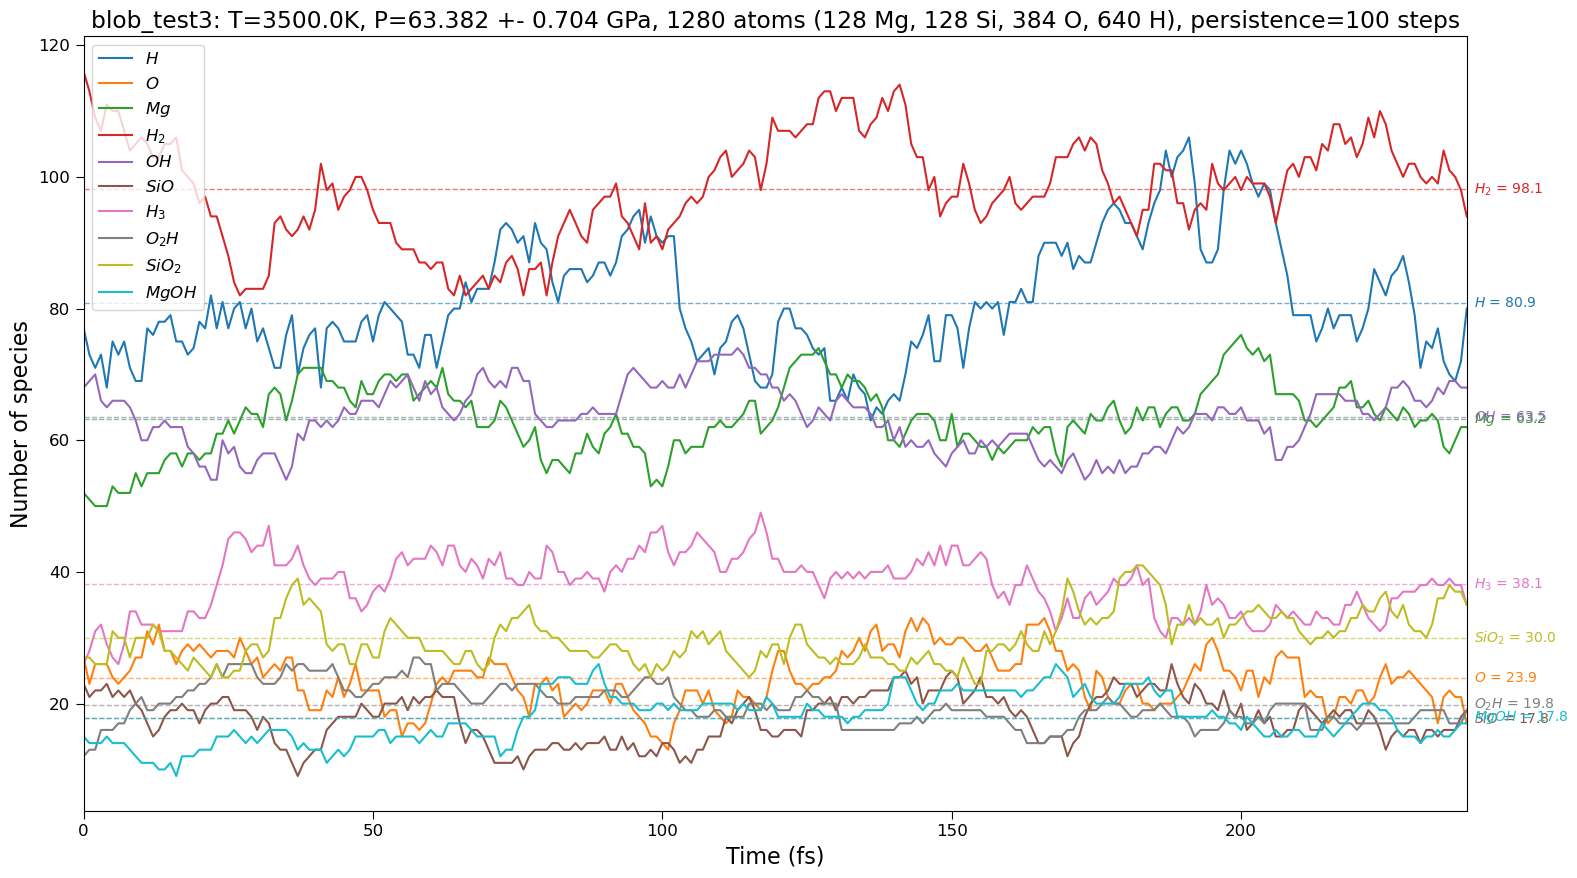

In [21]:
# ---- Plot: Species counts over time (top N) ----
dt_fs = sim_params["dt_sim_ps"] * 1000  # Convert ps to fs
time_axis = np.arange(len(num_species_all_T)) * dt_fs  # in fs

fig, ax = plt.subplots(figsize=(16, 9))

for plot_i, (label_latex, key) in enumerate(zip(top_formula_labels_latex, top_species_keys)):
    col_idx = species_keys.index(key)
    mean_val = mean_counts[col_idx]
    ax.plot(time_axis, counts_array[:, col_idx], label=label_latex, color=f"C{plot_i}")
    ax.axhline(
        mean_val, color=f"C{plot_i}", linestyle="--", linewidth=1, alpha=0.6
    )
    ax.annotate(
        f"{label_latex} = {mean_val:.1f}",
        xy=(time_axis[-1], mean_val),
        xytext=(5, 0),
        textcoords="offset points",
        color=f"C{plot_i}",
        fontsize=10,
        va="center",
    )

ax.set_xlabel("Time (fs)")
ax.set_ylabel("Number of species")
ax.set_title(
    f"{run_id}: T={sim_params['temperature_K']}K, P={sim_params['pressure_str']}, "
    f"{n_atoms_total} atoms ({', '.join(f'{len(ag)} {el}' for el, ag in atom_groups.items())}), "
    f"persistence={bond_persistence_steps} steps"
)
ax.legend(loc="best")
ax.set_xlim(time_axis[0], time_axis[-1])
plt.tight_layout()

fig.savefig(os.path.join(output_dir, "species_counts_vs_time.png"), dpi=150)
print(f"Saved: {os.path.join(output_dir, 'species_counts_vs_time.png')}")
plt.show()

Saved: /projects/JIEDENG/akashgpt/shared_w_Donghao/For_Akash/blob_test3/analysis/speciation/species_percentages_vs_time.png


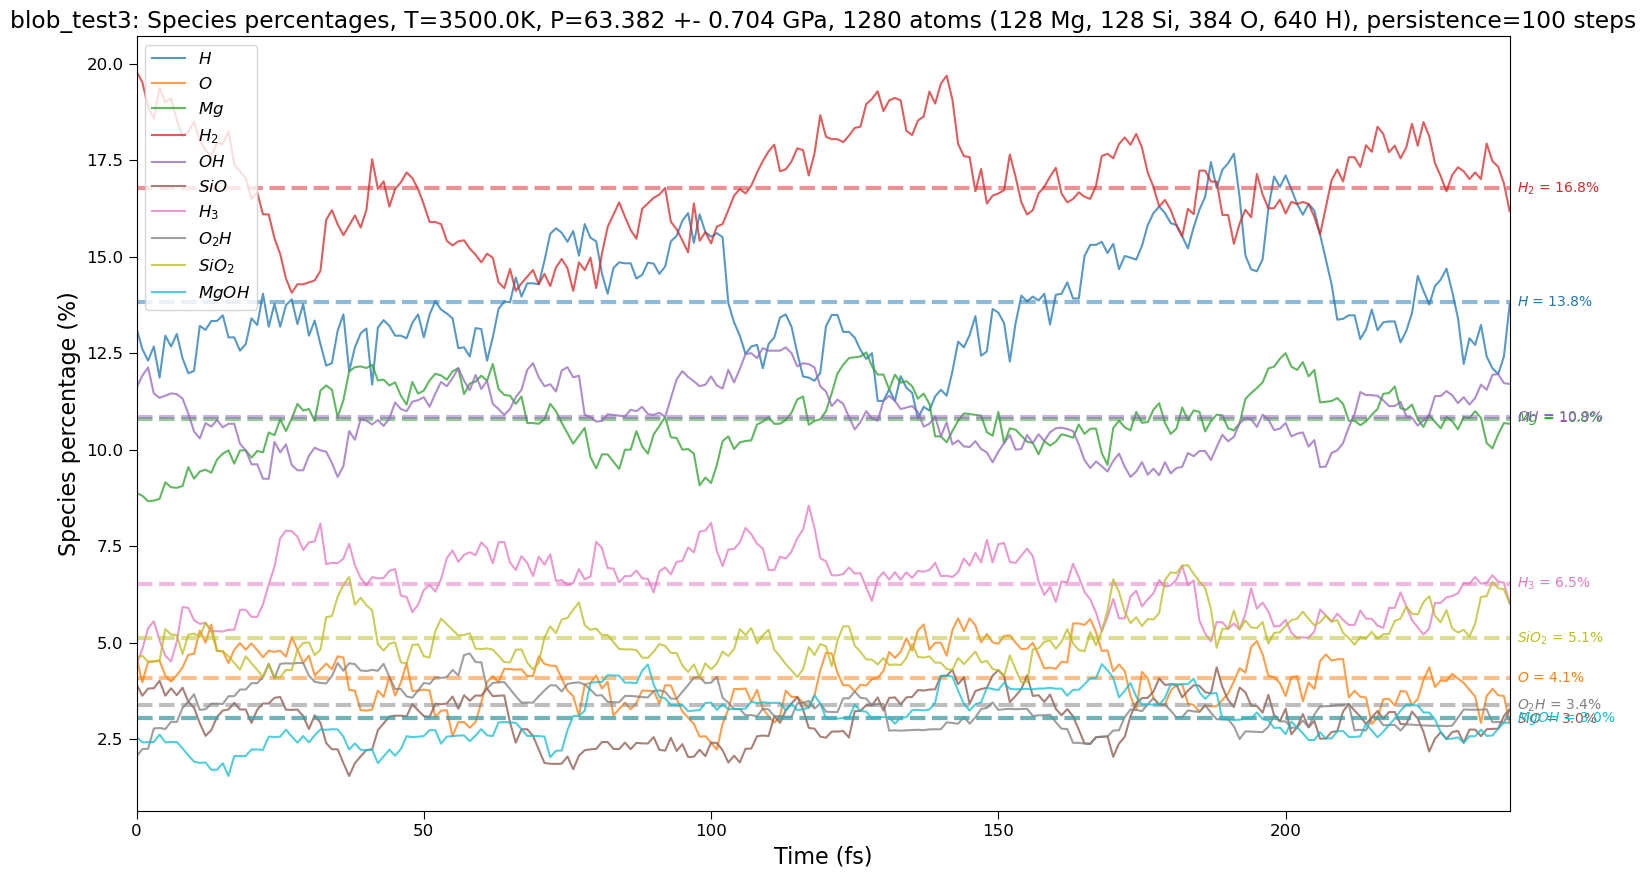

In [22]:
# ---- Plot: Species percentages over time (top N) ----
total_species = np.sum(counts_array, axis=1, keepdims=True)
# Avoid division by zero
total_species = np.where(total_species == 0, 1, total_species)
percentages = counts_array / total_species * 100

fig, ax = plt.subplots(figsize=(16, 9))

for plot_i, (label_latex, key) in enumerate(zip(top_formula_labels_latex, top_species_keys)):
    col_idx = species_keys.index(key)
    mean_pct = np.mean(percentages[:, col_idx])
    ax.plot(time_axis, percentages[:, col_idx], label=label_latex, color=f"C{plot_i}", alpha=0.75)
    ax.axhline(
        mean_pct, color=f"C{plot_i}", linestyle="--", linewidth=3, alpha=0.5
    )
    ax.annotate(
        f"{label_latex} = {mean_pct:.1f}%",
        xy=(time_axis[-1], mean_pct),
        xytext=(5, 0),
        textcoords="offset points",
        color=f"C{plot_i}",
        fontsize=10,
        va="center",
    )

ax.set_xlabel("Time (fs)")
ax.set_ylabel("Species percentage (%)")
ax.set_title(
    f"{run_id}: Species percentages, T={sim_params['temperature_K']}K, P={sim_params['pressure_str']}, "
    f"{n_atoms_total} atoms ({', '.join(f'{len(ag)} {el}' for el, ag in atom_groups.items())}), "
    f"persistence={bond_persistence_steps} steps"
)
ax.legend(loc="best")
ax.set_xlim(time_axis[0], time_axis[-1])
plt.tight_layout()

fig.savefig(os.path.join(output_dir, "species_percentages_vs_time.png"), dpi=150)
print(f"Saved: {os.path.join(output_dir, 'species_percentages_vs_time.png')}")
plt.show()

In [ ]:
# ---- Summary table (all species) ----
# Compute percentages (each species count / total species count at that timestep * 100)
total_per_step = np.sum(counts_array, axis=1, keepdims=True)
total_per_step = np.where(total_per_step == 0, 1, total_per_step)
pct_array = counts_array / total_per_step * 100

print(f"\n{'='*130}")
print(f"Speciation Summary for {run_id}")
print(f"T = {sim_params['temperature_K']} K, P = {sim_params['pressure_str']}")
print(f"Frames analyzed: {len(num_species_all_T)}")
print(f"Persistence window: {bond_persistence_steps} steps ({bond_persistence_steps * sim_params['dt_sim_ps']*1000:.1f} fs)")
print(f"Neighbor rank cutoff: {neighbor_rank_cutoff}")
print(f"Species detected: {n_total_species}")
print(f"{'='*130}")
print(f"{'Species':>10s}  {'Mean':>8s}  {'P2.5':>8s}  {'P97.5':>8s}  {'Min':>6s}  {'Max':>6s}"
      f"  |  {'Pct Mean':>9s}  {'P2.5':>8s}  {'P97.5':>8s}  {'Pct Min':>8s}  {'Pct Max':>8s}")
print(f"{'-'*130}")
for i in ranked_indices:
    label = formula_labels_unicode[i]
    col = counts_array[:, i]
    pct_col = pct_array[:, i]
    mc = mean_counts[i]
    mp = np.mean(pct_col)
    cp2_5, cp97_5 = np.percentile(col, [2.5, 97.5])
    pp2_5, pp97_5 = np.percentile(pct_col, [2.5, 97.5])
    if mc > 0.001:
        print(f"{label:>10s}  {mc:8.2f}  {cp2_5:8.0f}  {cp97_5:8.0f}  {np.min(col):6.0f}  {np.max(col):6.0f}"
              f"  |  {mp:8.2f}%  {pp2_5:7.2f}%  {pp97_5:7.2f}%  {np.min(pct_col):7.2f}%  {np.max(pct_col):7.2f}%")
print(f"{'='*130}")

## 8. Export Results

In [ ]:
# ---- Save species counts to CSV (all species) ----
csv_path = os.path.join(output_dir, "speciation_counts.csv")

with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["frame"] + formula_labels)
    for t_idx in range(len(num_species_all_T)):
        row = [t_idx + bond_persistence_steps]
        for s_idx in range(len(species_keys)):
            row.append(int(counts_array[t_idx, s_idx]))
        writer.writerow(row)

print(f"Species counts saved to {csv_path}")

# ---- Save summary statistics (all species, counts + percentages) ----
summary_path = os.path.join(output_dir, "speciation_summary.csv")

# Recompute percentages if not already available
total_per_step = np.sum(counts_array, axis=1, keepdims=True)
total_per_step = np.where(total_per_step == 0, 1, total_per_step)
pct_array = counts_array / total_per_step * 100

with open(summary_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "species", "composition",
        "count_mean", "count_p2.5", "count_p97.5", "count_min", "count_max",
        "pct_mean", "pct_p2.5", "pct_p97.5", "pct_min", "pct_max",
    ])
    for i in ranked_indices:
        label = formula_labels[i]
        key = species_keys[i]
        col = counts_array[:, i]
        pct_col = pct_array[:, i]
        cp2_5, cp97_5 = np.percentile(col, [2.5, 97.5])
        pp2_5, pp97_5 = np.percentile(pct_col, [2.5, 97.5])
        writer.writerow([
            label,
            str(key),
            f"{np.mean(col):.4f}",
            f"{cp2_5:.4f}",
            f"{cp97_5:.4f}",
            f"{np.min(col):.0f}",
            f"{np.max(col):.0f}",
            f"{np.mean(pct_col):.4f}",
            f"{pp2_5:.4f}",
            f"{pp97_5:.4f}",
            f"{np.min(pct_col):.4f}",
            f"{np.max(pct_col):.4f}",
        ])

print(f"Summary saved to {summary_path}")

# ---- Save run info (separated into categories) ----
info_path = os.path.join(output_dir, "run_info.csv")

info_rows = [
    # -- Simulation Info --
    ("category", "simulation_info"),
    ("run_id", run_id),
    ("sim_format", sim_format),
    ("run_dir", run_dir),
    ("temperature_K", sim_params["temperature_K"]),
    ("pressure", sim_params["pressure_str"]),
    ("dt_sim_fs", sim_params["dt_sim_ps"] * 1000),
    ("n_atoms_total", n_atoms_total),
    ("elements", " ".join(elements)),
    ("atoms_per_element", " ".join(f"{len(atom_groups[el])}" for el in elements)),
    ("element_boundaries", " ".join(str(b) for b in boundaries)),
    ("n_frames_total", n_frames_total),
    ("box_a", f"{sim_params['a_box']:.4f}"),
    ("box_b", f"{sim_params['b_box']:.4f}"),
    ("box_c", f"{sim_params['c_box']:.4f}"),
    # -- Reproducibility Parameters --
    ("category", "reproducibility_params"),
    ("frame_start_cfg", repr(frame_start_cfg)),
    ("frame_end_cfg", repr(frame_end_cfg)),
    ("frame_start", frame_start),
    ("frame_end", frame_end),
    ("n_frames_analyzed", n_frames_analyze),
    ("max_cluster_size", max_cluster_size),
    ("min_cluster_size", min_cluster_size),
    ("neighbor_rank_cutoff", neighbor_rank_cutoff),
    ("bond_persistence_steps", bond_persistence_steps),
    ("top_n_species", top_n_species),
    # -- Results --
    ("category", "results"),
    ("output_dir", output_dir),
    ("n_species_detected", n_total_species),
]

with open(info_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["parameter", "value"])
    writer.writerows(info_rows)

print(f"Run info saved to {info_path}")
print(f"\nAll outputs in: {output_dir}")

## 9. Run Summary

Run this cell to view a full summary of the analysis configuration, simulation
parameters, and output locations — without stepping through previous sections.

In [ ]:
# ---- Print full run summary ----
# This cell can be run standalone after the notebook completes to review
# all key parameters and output paths at a glance.

print(f"{'='*65}")
print(f"  RUN SUMMARY")
print(f"{'='*65}")

# --- Simulation Info ---
print(f"\n--- Simulation Info ---")
print(f"  Run ID:          {run_id}")
print(f"  Format:          {sim_format.upper()} ({'VASP AIMD' if sim_format == 'vasp' else 'LAMMPS classical/reactive MD'})")
print(f"  Run directory:   {run_dir}")
print(f"  Temperature:     {sim_params['temperature_K']} K")
print(f"  Pressure:        {sim_params['pressure_str']}")
print(f"  Timestep:        {sim_params['dt_sim_ps']*1000:.1f} fs")
print(f"  Box (a,b,c):     {sim_params['a_box']:.2f}, {sim_params['b_box']:.2f}, {sim_params['c_box']:.2f} Ang")
print(f"  Total atoms:     {n_atoms_total}")
print(f"  Elements:        {', '.join(f'{len(atom_groups[el])} {el}' for el in elements)}")
print(f"  Total frames:    {n_frames_total}")

# --- Reproducibility Parameters ---
print(f"\n--- Reproducibility Parameters ---")
print(f"  frame_start_cfg: {frame_start_cfg!r}  ->  frame {frame_start}")
print(f"  frame_end_cfg:   {frame_end_cfg!r}  ->  frame {frame_end}")
print(f"  Frames analyzed: {n_frames_analyze} ({n_frames_analyze/n_frames_total*100:.1f}%)")
print(f"  Cluster size:    {min_cluster_size} to {max_cluster_size} atoms")
print(f"  Neighbor cutoff: rank <= {neighbor_rank_cutoff}")
print(f"  Persistence:     {bond_persistence_steps} steps ({bond_persistence_steps * sim_params['dt_sim_ps']*1000:.1f} fs)")
print(f"  top_n_species:   {top_n_species} (plots only)")

# --- Results ---
print(f"\n--- Results ---")
print(f"  Species detected:  {n_total_species}")

# --- Output ---
print(f"\n--- Output Directory ---")
print(f"  {output_dir}")
print(f"    ├── speciation_counts.csv   (all {n_total_species} species)")
print(f"    ├── speciation_summary.csv  (all {n_total_species} species)")
print(f"    ├── run_info.csv")
print(f"    ├── species_counts_vs_time.png    (top {n_shown})")
print(f"    └── species_fractions_vs_time.png (top {n_shown})")
print(f"{'='*65}")